# Sentiment Analysis

**Objective**

The objective of this project is to analyze movie reviews from the IMDB dataset and identify whether they express positive or negative sentiment. Using Python and NLP techniques, the project visualizes sentiment patterns and explores review characteristics through charts and word clouds.

#Load the Dataset

In [1]:
#Connect with google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

# Display graphs inside Colab
sns.set_theme(style="whitegrid")
%matplotlib inline

In [3]:
#Import Data Set
df = pd.read_csv("/content/drive/MyDrive/CodeAlpha/IMDB_cleaned.csv")

# Dataset Summary

In [4]:
#General information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4997 entries, 0 to 4996
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   review                     4997 non-null   object
 1   cleaned_review             4997 non-null   object
 2   sentiment                  4997 non-null   object
 3   review_word_count          4997 non-null   int64 
 4   cleaned_review_word_count  4997 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 195.3+ KB


In [5]:
#Dataset shape
print(df.shape)

(4997, 5)


In [6]:
#Column names
df.columns

Index(['review', 'cleaned_review', 'sentiment', 'review_word_count',
       'cleaned_review_word_count'],
      dtype='object')

In [7]:
#Data types
df.dtypes

,0
review,object
cleaned_review,object
sentiment,object
review_word_count,int64
cleaned_review_word_count,int64


In [8]:
#Display first 5 rows
display(df.head())

,review,cleaned_review,sentiment,review_word_count,cleaned_review_word_count
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,positive,307,314
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...,positive,162,160
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,positive,166,167
3,Basically there's a family where a little boy ...,basically there is a family where a little boy...,negative,138,133
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...,positive,230,228


In [9]:
#Summary statistics
df.describe()

,review_word_count,cleaned_review_word_count
count,4997.000000,4997.000000
mean,231.253152,234.147889
std,170.989918,172.789274
min,14.000000,14.000000
25%,126.000000,128.000000
50%,172.000000,175.000000
75%,285.000000,288.000000
max,1737.000000,1735.000000


# Data Preparation

The dataset used in this project is a preprocessed (cleaned) IMDB movie review dataset. Since the text has already been cleaned and prepared, no additional preprocessing, missing value handling, or duplicate removal was required. The analysis focuses on exploring sentiment patterns and visualizing the results.

#Sentiment Distribution



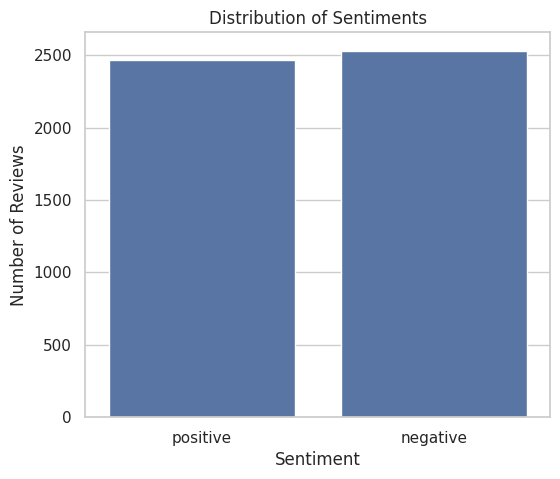

In [10]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

This chart shows the number of positive and negative reviews in the dataset.

#Review Length Distribution

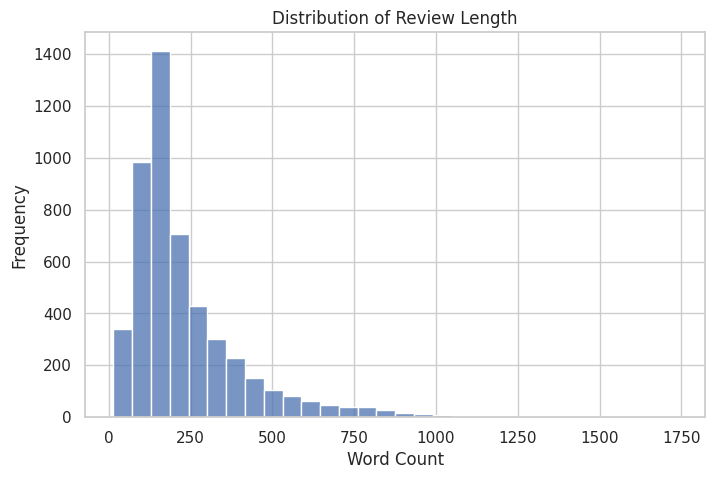

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="review_word_count",
    bins=30
)

plt.title("Distribution of Review Length")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

plt.show()

Most reviews have a moderate number of words, while only a few reviews are extremely long.

#Review Length by Sentiment

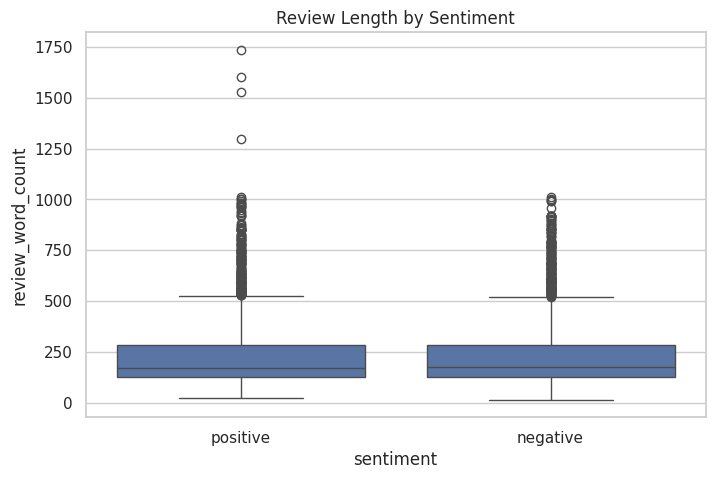

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="sentiment",
    y="review_word_count"
)

plt.title("Review Length by Sentiment")

plt.show()

This box plot compares the distribution of review lengths for positive and negative sentiments.

#Word Cloud (Positive Reviews)

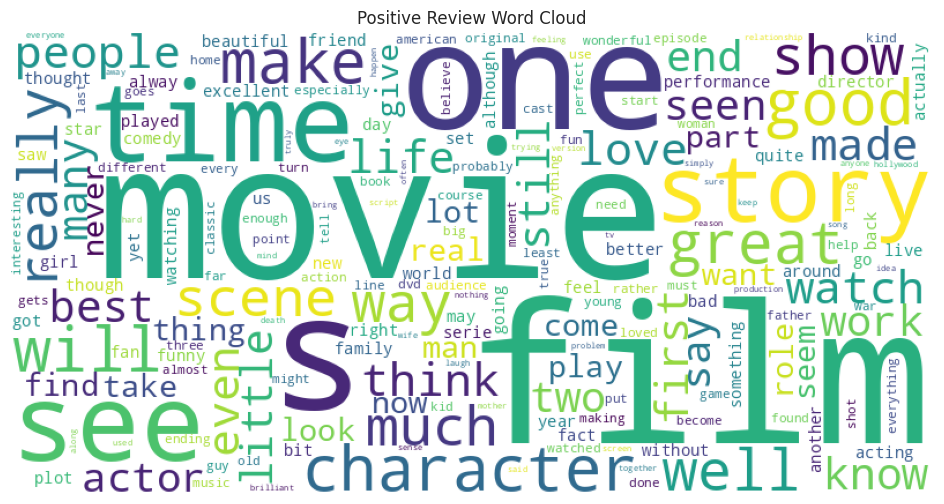

In [13]:
positive_text = " ".join(
    df[df["sentiment"]=="positive"]["cleaned_review"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Review Word Cloud")
plt.show()

Frequently used words in positive reviews appear larger in the word cloud.

#Word Cloud (Negative Reviews)

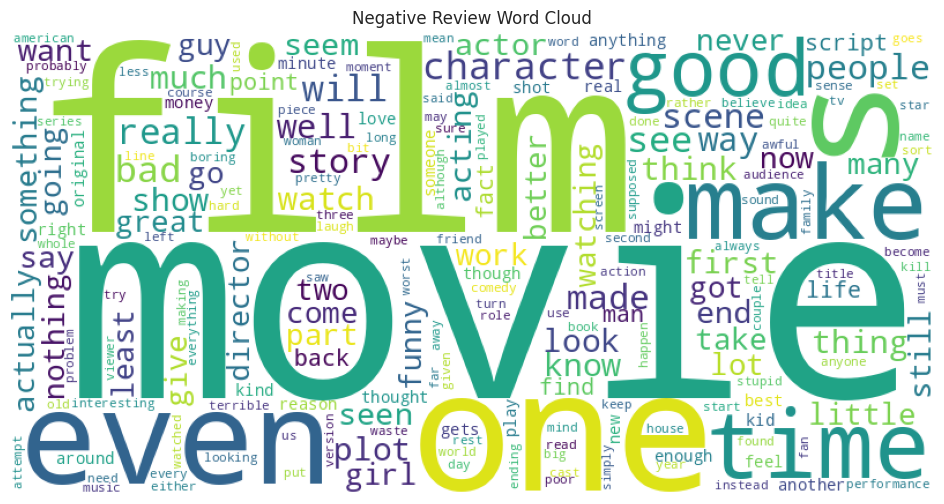

In [14]:
negative_text = " ".join(
    df[df["sentiment"]=="negative"]["cleaned_review"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Review Word Cloud")
plt.show()

#Top 20 Words (Positive Reviews)

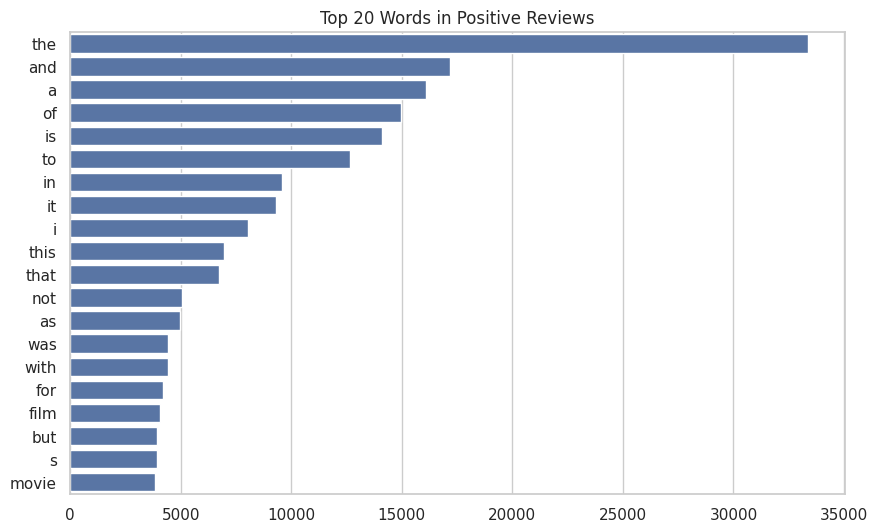

In [15]:
positive_words = positive_text.split()

common_positive = Counter(positive_words).most_common(20)

words = [w for w, c in common_positive]
counts = [c for w, c in common_positive]

plt.figure(figsize=(10,6))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Top 20 Words in Positive Reviews")

plt.show()

#Top 20 Words (Negative Reviews)

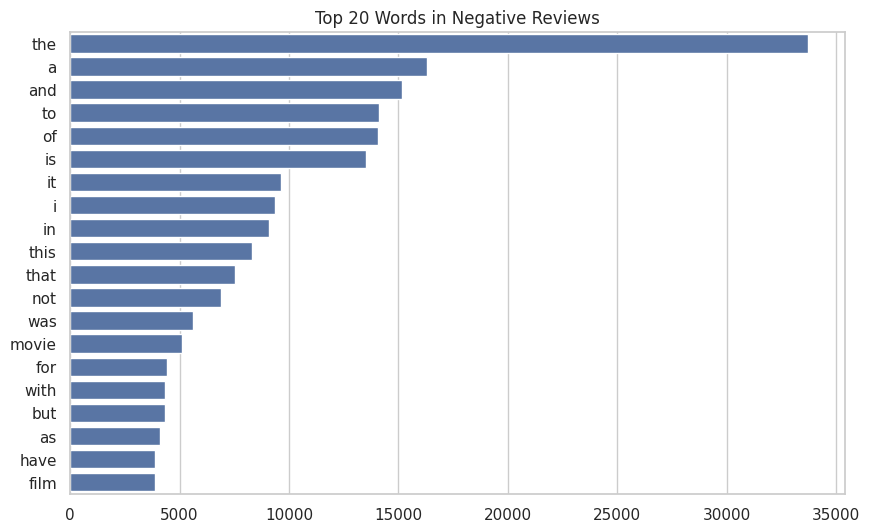

In [16]:
negative_words = negative_text.split()

common_negative = Counter(negative_words).most_common(20)

words = [w for w, c in common_negative]
counts = [c for w, c in common_negative]

plt.figure(figsize=(10,6))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Top 20 Words in Negative Reviews")

plt.show()

#

# Key Insights


* The dataset contains both positive and negative movie reviews.

* Review lengths vary across sentiments.

* Positive reviews frequently use words expressing enjoyment and appreciation.

* Negative reviews contain more words associated with disappointment and criticism.

* Word clouds effectively highlight the most common terms used in each sentiment category.

#Conclusions

This project analyzed IMDB movie reviews using sentiment analysis techniques. Through visualizations such as sentiment distribution, review length analysis, word clouds, and word frequency charts, the project identified patterns in positive and negative reviews. These insights demonstrate how Natural Language Processing (NLP) can be used to understand customer opinions and support data-driven decision-making.

#